# **Diabetes Data Analisys**
## **Comparing patient groups by readmission **

**Importing Dataset**

In [ ]:
# Importing all neccesary libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Importing the dataset
df = pd.read_csv("https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv")

**Data Exploration**

In [ ]:

df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
print("Shape:",df.shape)

Shape: (101766, 50)


In [ ]:
# Checking columns names and data type
print(df.dtypes)

encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glimepiride         

In [ ]:
#Since the df.head() game me the first 5 weights as "?", need to check if I have a value depending on age group
print(df['weight'].value_counts(dropna=False))

weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64


In [ ]:
# Verifying unique values in columns to set my comparisson points
print("Readmitted values:", df['readmitted'].unique())
print("Genders:    ", df['gender'].unique())
print("Ages:       ", df['age'].unique())

Readmitted values: ['NO' '>30' '<30']
Genders:     ['Female' 'Male' 'Unknown/Invalid']
Ages:        ['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']


**Data Cleaning**

In [ ]:
# Replacing all "?" with NaN values
df.replace('?', np.nan, inplace=True)

In [ ]:
# Checking the 3 columns with most missing values
missing_pct = df.isna().sum() / len(df) * 100
print(missing_pct.sort_values(ascending=False))

weight                      96.858479
max_glu_serum               94.746772
A1Cresult                   83.277322
medical_specialty           49.082208
payer_code                  39.557416
race                         2.233555
diag_3                       1.398306
diag_2                       0.351787
diag_1                       0.020636
patient_nbr                  0.000000
time_in_hospital             0.000000
admission_source_id          0.000000
num_lab_procedures           0.000000
encounter_id                 0.000000
admission_type_id            0.000000
discharge_disposition_id     0.000000
gender                       0.000000
age                          0.000000
number_inpatient             0.000000
number_emergency             0.000000
number_outpatient            0.000000
num_medications              0.000000
num_procedures               0.000000
number_diagnoses             0.000000
metformin                    0.000000
repaglinide                  0.000000
nateglinide 

For comparison reason I don't need Weight, payer code and/or specialty, therefore I will remove thos 3 columns

In [ ]:
df.drop(columns=['weight','payer_code','medical_specialty'],inplace=True)
print('Shape:',df.shape) #making sure unnecessary columns were dropped

Shape: (101766, 47)


In [ ]:
#Since I have a "Unknown" gender, counting the amount of fields that does not have any gender
print(df['gender'].value_counts())

gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


In [ ]:
# Dropping all "unknowns" rowns for gender
df['gender'] = df['gender'].replace('Unknown/Invalid', pd.NA)
df.dropna(subset=['gender'], inplace=True)

**Comparing Data**

In previous line one see that readmitted can have 3 values <30 , >30 or NO, lets create a new column to simplify this values in yes or no to facilitate the comparison  

In [ ]:
# Create an empty list to store the new values
readmitted_simplified = []

# Loop through every value in the readmitted column
for value in df['readmitted']:
    if value == '<30' or value == '>30':
        readmitted_simplified.append('YES')
    else:
        readmitted_simplified.append('NO')

# Add the list as a new column in the dataframe
df['readmitted_simplified'] = readmitted_simplified

print(df['readmitted_simplified'].value_counts()) #printing values to verify all counts

readmitted_simplified
NO     54861
YES    46902
Name: count, dtype: int64


In [ ]:
# df.describe of the data set
print(df.groupby('readmitted_simplified')['num_medications'].describe().round(2))

# Mean and median of readmitted Vs not readmited
print("\nMean number of medications:")
print(df.groupby('readmitted_simplified')['num_medications'].mean().round(2))

print("\nMedian number of medications:")
print(df.groupby('readmitted_simplified')['num_medications'].median())

                         count   mean   std  min   25%   50%   75%   max
readmitted_simplified                                                   
NO                     54861.0  15.67  8.43  1.0  10.0  14.0  20.0  79.0
YES                    46902.0  16.43  7.74  1.0  11.0  15.0  20.0  81.0

Mean number of medications:
readmitted_simplified
NO     15.67
YES    16.43
Name: num_medications, dtype: float64

Median number of medications:
readmitted_simplified
NO     14.0
YES    15.0
Name: num_medications, dtype: float64


**Visualizations**

Text(0, 0.5, 'Number of Medications')

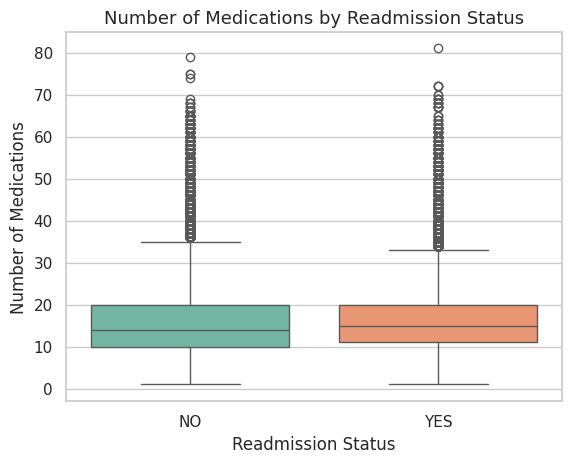

In [ ]:
# Box Plot
sns.boxplot(data=df,x='readmitted_simplified',y='num_medications',hue='readmitted_simplified',legend=False)
plt.title('Number of Medications by Readmission Status', fontsize=13)
plt.xlabel('Readmission Status')
plt.ylabel('Number of Medications')


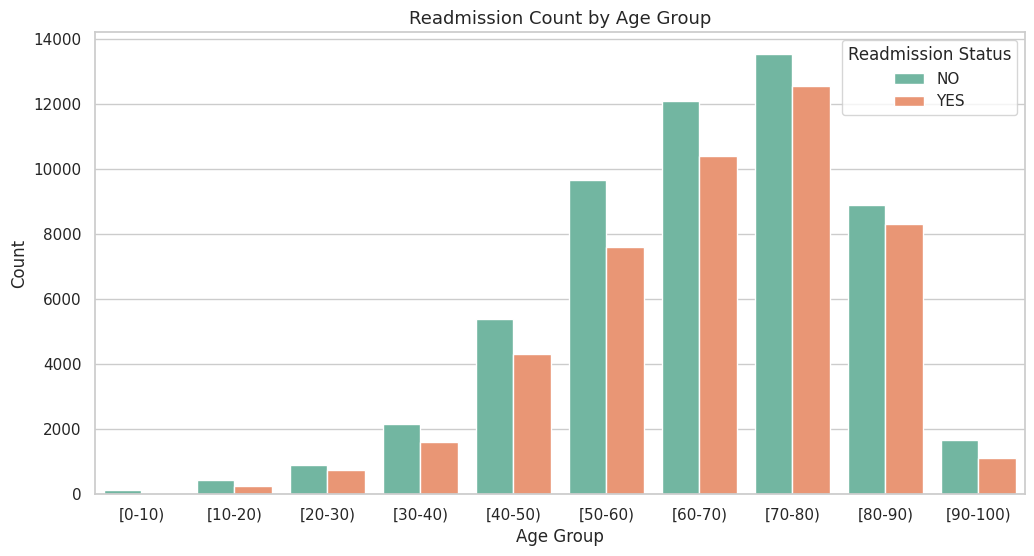

In [ ]:
# Readmissions by Age Group
plt.figure(figsize=(12, 6))
sns.countplot(data=df,x='age',hue='readmitted_simplified',palette='Set2',order=sorted(df['age'].dropna().unique()))
plt.title('Readmission Count by Age Group', fontsize=13)
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Readmission Status')

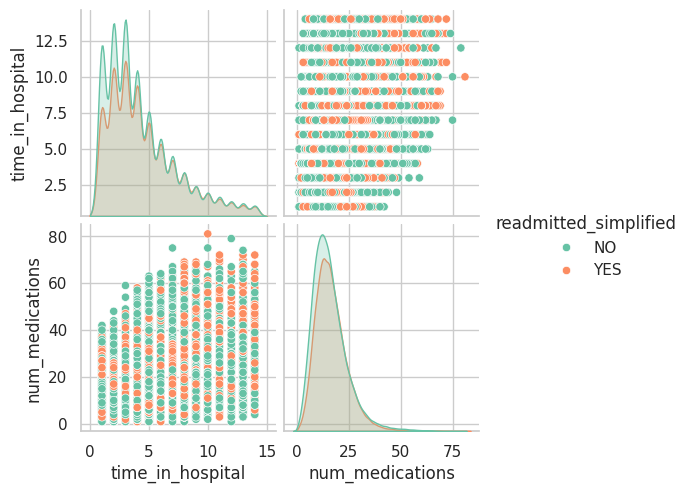

In [ ]:
# Pairplot of the data set
sns.pairplot(df[['time_in_hospital', 'num_medications','readmitted_simplified']],hue='readmitted_simplified')

**Conclusion**

After analyzing the diabetes dataset, I found two interesting patterns. First, patients who were readmitted to the hospital were prescribed more medications on average (16.43) compared to patients who were not readmitted (15.67). This could mean that recurrent patients need more medications to manage their diabetes, which also makes them more likely to return to the hospital. Second, when looking at age groups, patients between 70 and 80 years old had the highest readmission rates. This suggests that older patients may have a harder time managing diabetes, making age an important factor to consider when looking at readmission risk. Overall, both the number of medications and the patient's age seem to be related to whether or not a patient gets readmitted.